## Ejemplo 1

In [8]:
import sympy as sp

# 1. Definimos los símbolos
z = sp.Symbol('z')
X = sp.Symbol('X') # Representa X(z)
Y = sp.Symbol('Y') # Representa Y(z)
alpha = sp.Symbol('alpha', real=True)

In [9]:
# 2. Definimos la ecuación en diferencias aplicando la regla del retardo directamente
# y[n] -> Y
# x[n] -> X
# y[n-1] -> Y * z**-1
eq_1er_orden = sp.Eq(Y, alpha * X + (1 - alpha) * (Y * z**-1))

print("1. Ecuación en el dominio Z:")
sp.pprint(eq_1er_orden)

1. Ecuación en el dominio Z:
          Y⋅(1 - α)
Y = X⋅α + ─────────
              z    


In [10]:
# 3. Resolvemos algebraicamente para Y(z)
Y_sol = sp.solve(eq_1er_orden, Y)[0]

# 4. Obtenemos H(z) dividiendo entre X(z)
H_z_1 = sp.simplify(Y_sol / X)

print("\n2. Función de Transferencia H(z) del 1er orden:")
sp.pprint(H_z_1)


2. Función de Transferencia H(z) del 1er orden:
   α⋅z   
─────────
α + z - 1


## Ejemplo 2

<>:48: SyntaxWarning: invalid escape sequence '\m'
<>:49: SyntaxWarning: invalid escape sequence '\m'
<>:48: SyntaxWarning: invalid escape sequence '\m'
<>:49: SyntaxWarning: invalid escape sequence '\m'
C:\Users\47470482\AppData\Local\Temp\ipykernel_14640\3089626988.py:48: SyntaxWarning: invalid escape sequence '\m'
  ax.set_xlabel('Eje Real ($\mathbb{R}$)', fontsize=12)
C:\Users\47470482\AppData\Local\Temp\ipykernel_14640\3089626988.py:49: SyntaxWarning: invalid escape sequence '\m'
  ax.set_ylabel('Eje Imaginario ($j\mathbb{I}$)', fontsize=12)


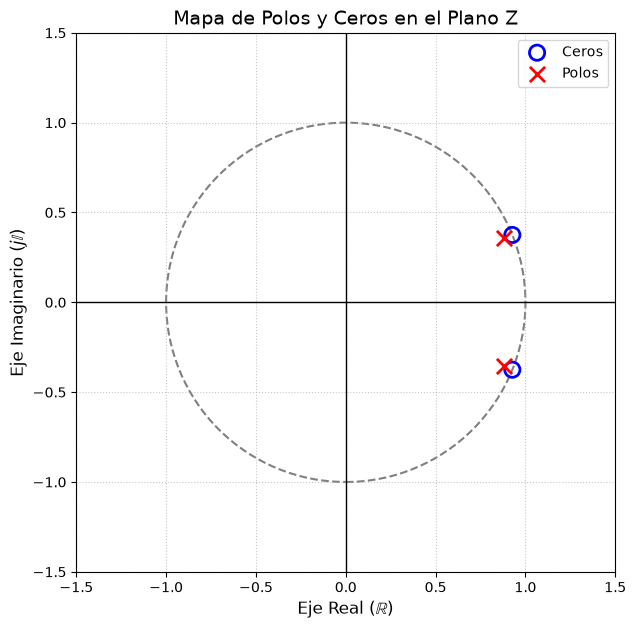

In [11]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

# 1. Definir la función de transferencia H(z)
z = sp.Symbol('z')

# Ejemplo: Coeficientes de un filtro Notch de 2do orden
numerador = z**2 - 1.854*z + 1
denominador = z**2 - 1.761*z + 0.9025

H_z = numerador / denominador

# 2. Extraer polos y ceros usando SymPy
# sp.roots devuelve un diccionario {raiz: multiplicidad}. Tomamos solo las claves.
ceros_sym = sp.roots(numerador, z)
polos_sym = sp.roots(denominador, z)

# Convertir las raíces simbólicas de SymPy a números complejos nativos de Python
ceros = [complex(c.evalf()) for c in ceros_sym.keys()]
polos = [complex(p.evalf()) for p in polos_sym.keys()]

# 3. Configurar el lienzo de Matplotlib
fig, ax = plt.subplots(figsize=(7, 7))

# Dibujar el círculo unitario
circulo = plt.Circle((0, 0), 1, color='gray', fill=False, linestyle='--', linewidth=1.5)
ax.add_patch(circulo)

# Dibujar los ejes coordenados (Real e Imaginario)
ax.axhline(y=0, color='k', linestyle='-', linewidth=1)
ax.axvline(x=0, color='k', linestyle='-', linewidth=1)

# 4. Graficar Ceros (o) y Polos (x)
# Extraemos las partes reales e imaginarias de las listas complejas
ax.scatter([np.real(c) for c in ceros], [np.imag(c) for c in ceros], 
           s=120, edgecolors='blue', facecolors='none', marker='o', 
           linewidth=2, label='Ceros')

ax.scatter([np.real(p) for p in polos], [np.imag(p) for p in polos], 
           s=120, color='red', marker='x', 
           linewidth=2, label='Polos')

# 5. Ajustes estéticos del gráfico
ax.set_aspect('equal') # Crucial: asegura que el círculo no se vea ovalado
ax.set_xlim([-1.5, 1.5])
ax.set_ylim([-1.5, 1.5])
ax.set_xlabel('Eje Real ($\mathbb{R}$)', fontsize=12)
ax.set_ylabel('Eje Imaginario ($j\mathbb{I}$)', fontsize=12)
ax.set_title('Mapa de Polos y Ceros en el Plano Z', fontsize=14)
ax.grid(True, linestyle=':', alpha=0.7)
ax.legend(loc='upper right')

plt.show()

## Ejemplo 3


In [1]:
import sympy as sp

In [2]:
# 1. Definimos las variables simbólicas
n = sp.Symbol('n', integer=True)
z = sp.Symbol('z', complex=True)
a = sp.Symbol('a', complex=True)

In [3]:

# 2. Definimos una señal de ejemplo, por ejemplo un decaimiento exponencial: x[n] = a^n
x_n = a**n

# 3. Aplicamos la fórmula de la Transformada Z unilateral
# Sumatoria desde n=0 hasta el infinito (sp.oo)
X_z = sp.summation(x_n * z**(-n), (n, 0, sp.oo))

print("Transformada Z de a^n:")
sp.pprint(X_z.simplify())

Transformada Z de a^n:
⎧     z            │a│    
⎪   ──────     for │─│ < 1
⎪   -a + z         │z│    
⎪                         
⎪  ∞                      
⎪ ___                     
⎨ ╲                       
⎪  ╲    n  -n             
⎪  ╱   a ⋅z     otherwise 
⎪ ╱                       
⎪ ‾‾‾                     
⎪n = 0                    
⎩                         


In [5]:
X_z

Piecewise((1/(-a/z + 1), Abs(a/z) < 1), (Sum(a**n/z**n, (n, 0, oo)), True))

## Ejemplo 2

In [6]:
import sympy as sp

# Definimos las variables simbólicas
z = sp.Symbol('z', complex=True)
r = sp.Symbol('r', real=True, positive=True) # Factor de calidad/ancho de banda
w0 = sp.Symbol('omega_0', real=True)         # Frecuencia de corte normalizada

# Definimos H(z) en potencias positivas de z
numerador = z**2 - 2*sp.cos(w0)*z + 1
denominador = z**2 - 2*r*sp.cos(w0)*z + r**2
H_z = numerador / denominador

print("Función de Transferencia H(z):")
sp.pprint(H_z)

# Extraer polos y ceros
# sp.roots devuelve un diccionario {raiz: multiplicidad}
ceros = sp.solve(numerador, z)
polos = sp.solve(denominador, z)

print("\nCeros del filtro:")
for cero in ceros:
    sp.pprint(cero.simplify())

print("\nPolos del filtro:")
for polo in polos:
    sp.pprint(polo.simplify())

Función de Transferencia H(z):
  2                    
 z  - 2⋅z⋅cos(ω₀) + 1  
───────────────────────
 2                    2
r  - 2⋅r⋅z⋅cos(ω₀) + z 

Ceros del filtro:
cos(ω₀) - ⅈ⋅│sin(ω₀)│
cos(ω₀) + ⅈ⋅│sin(ω₀)│

Polos del filtro:
r⋅(cos(ω₀) - ⅈ⋅│sin(ω₀)│)
r⋅(cos(ω₀) + ⅈ⋅│sin(ω₀)│)
